# GLM-HMM: How to set it up

In this notebook, we will use NeMoS to model choice data using Generalized Linear Models Hidden Markov Models (GLM-HMMs). We will explain what GLM-HMMs are and which are their components, then use NeMoS to characterize hidden states underlying decision making behavior in simulated data. Finally, we will analyse real choice data and reproduce figures X and Y from Ashwood et al. (2022).

In the analysis part, we will be use data from the International Brain Laboratory (IBL). This dataset contains information from choices of mice undergoing a binary perceptual decision making task, developed by CITATION. For simplicity, we will focus on the decisions of one mouse.

We have N main goals in this notebook:
1. Introduce the key components of GLM-HMMs
2. Generate simulated choices under a GLM-HMM using NeMoS
3. Fit simulated data to a GLM-HMM (recovery analysis) using NeMoS
4. Reproduce figures from Ashwood et al. (2020) using a real mouse choice data.
5. Show the importance of a good choice of initial parameters for fitting GLM-HMMs

By the end of this notebook, you should have a clearer understanding of the fundamental building blocks of GLM-HMMs, as well as how NeMoS can streamline the process of modeling and analyzing hidden states underlying decision making, and how the dynamics of decision making upon input presentation change accordingly. You will also peek into the importance of choosing a good initialization method for fitting GLM-HMMs.

Importantly, throughout the notebook we will assume you already have a solid theoretical understanding of GLMs. If you need a refresher, please refer to XX. Moreover, if you already have a good understanding of GLM-HMMs and are interested in different heuristics you could use to overcome difficulties in the fitting process, please refer to XX for fine-grain details of the fitting algorithm and different initialization methods you could use to best describe your data.

## 1. Key components of GLM-HMMs
Simple intro explanation on GLM-HMMs

You need three things:
1. Initial probabilities
2. Projection Weights
Also called emission probabilities
3. Transition Probabilities

Further Explanation for each of them

## Setup

In [10]:
# Imports
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import nemos as nmo

# Set up and configuration
seed = 0  # Random seed for reproducibility
np.random.seed(seed)
jax.config.update("jax_enable_x64", True)

## Utils (will be moved to a different script)

In [11]:

# Utils
def plot_glm_weights(
    n_features,
    n_states,
    true_projection_weights,
    learned_intercept,
    learned_coef,
    X_labels,
    initialization_setting,
):
    ## Plot
    fig = plt.figure(figsize=(8, 6), dpi=80, facecolor="w", edgecolor="k")
    cols = ["#ff7f00", "#4daf4a", "#377eb8"]
    recovered_weights = np.zeros_like(true_projection_weights)

    recovered_weights[:1] = learned_intercept
    recovered_weights[1:] = learned_coef

    for k in range(n_states):
        if k == 0:
            plt.plot(
                range(n_features),
                true_projection_weights[:, k],
                marker="o",
                color=cols[k],
                linestyle="-",
                lw=1.5,
                label="Ashwood et al. (2022)",
            )
            plt.plot(
                range(n_features),
                recovered_weights[:, k],
                color=cols[k],
                lw=1.5,
                label="NeMoS GLM-HMM",
                linestyle="--",
            )
        else:
            plt.plot(
                range(n_features),
                true_projection_weights[:, k],
                marker="o",
                color=cols[k],
                linestyle="-",
                lw=1.5,
                label="",
            )

            plt.plot(
                range(n_features),
                recovered_weights[:, k],
                color=cols[k],
                lw=1.5,
                label="",
                linestyle="--",
            )
            
    
    plt.yticks(fontsize=10)
    plt.ylabel("GLM weight", fontsize=15)
    plt.xlabel("covariate", fontsize=15)
    plt.xticks([i for i in range(n_features)], X_labels, fontsize=12, rotation=45)
    plt.axhline(y=0, color="k", alpha=0.5, ls="--")
    plt.legend()
    plt.title(f"Weight recovery - {initialization_setting}", fontsize=15)
    plt.tight_layout()
    plt.savefig("figures/fig_07_glm_hmm_behavioral.png")

    plt.show()
    return None


def load_session_fold_lookup(file_path):
    '''By Ashwood
    '''
    container = np.load(file_path, allow_pickle=True)
    data = [container[key] for key in container]
    session_fold_lookup_table = data[0]
    return session_fold_lookup_table
session_fold_table = load_session_fold_lookup("IBL/CSHL_008_session_fold_lookup.npz")

def load_data(animal_file):
    '''By Ashwood
    '''
    container = np.load(animal_file, allow_pickle=True)
    data = [container[key] for key in container]
    inpt = data[0]
    y = data[1]
    session = data[2]
    return inpt, y, session


check if ibl dataset is in dandi or other archive. then we can use fetch data. see if i can download just one animal: https://elifesciences.org/articles/63711#abstract

## 2. Simulated choices and choice rates using NeMoS
Explanation of each simulation parameter. We are using these to match ssm tutorial and also ashwood paper parameter space

Remove intercept altogether from the simulation.


In [12]:
# SESSION PARAMETERS
n_sess = 20                                     # Number of sessions to simulate
n_trials_per_sess = 100                         # Number of trials in a session
n_timepoints = n_sess * n_trials_per_sess       # Total number of timepoints
new_sess = np.zeros(n_timepoints, dtype=int)    # Indicator for session starts
new_sess[::n_trials_per_sess] = 1               # Set 1 at the beginning of each session
# GLM-HMM parameters
n_states = 3           

Interpretation for the choice of initialization parameters

:::{admonition} A note on NeMoS handling of the bias term / intercept
:class: info
:class: dropdown


:::

In [13]:
# We will consider a design matrix with the following behavioral variables
X_labels = ["bias", "stimulus"]

n_features = len(X_labels) - 1  # Number of features in design matrix
                                # Substracting one because Nemos does not consider intercept as feature 

# Projection weights, using parameters from Ashwood et al. (2020)
true_projection_weights = np.array(
    [6, 2, 2], dtype=float  # Stimulus
)
true_intercept = np.array(
    [1, -3, 3],dtype=float  # Bias - Intercept
)


This initial probabilities put more weight to starting on the first state than the others two.

In [14]:
# Initial state probabilities
# Couldnt find exact numbers from fast check in Ashwood et al. - revise again
true_initial_prob = jnp.array([0.95, 0.025, 0.025])

:::{admonition} A note on transition matrices
:class: info
:class: dropdown
Types of matrices we'd like and we wouldnt like in terms of the properties of the transition matrix
- Explanation for sticky transitions
- No 0 proba transitions

:::

In [15]:
# Transition matrix
true_transition_prob = np.array(
    [[0.98, 0.01, 0.01], [0.04, 0.94, 0.02], [0.04, 0.01, 0.96]]
)


:::{admonition} A note on dimensions of GLM-HMM inputs
:class: info
:class: dropdown


:::

Refresher on task

In [16]:
# Stimuli shown to the "mice"
stim_vals = [
    -1,
    -0.5,
    -0.25,
    -0.125,
    -0.0625,
    0,
    0.0625,
    0.125,
    0.25,
    0.5,
    1,
]

# Generate random sequence of stimuli for simulation
X = np.random.choice(stim_vals, n_timepoints)
X = X.reshape(n_timepoints, n_features)

We choose a state at random, create a GLM for that state and simulate a count and choice probability as usual.
Using the transition probability matrix, we move from the first state to the following one, and we compute the choice and probability the same way. We store

In [17]:
# Simulation
# Initialize storage
true_latent_states = np.zeros((n_timepoints, n_states), dtype=int)  # n_timepoints, n_states
choice_probas = np.zeros((n_timepoints,))
true_choices = np.zeros((n_timepoints,))

# Simulate states and observations
initial_state = np.random.choice(n_states,
                                 p=true_initial_prob)
true_latent_states[0, initial_state] = 1                            # latent at timepoint 0

# Initialize GLM
glm = nmo.glm.GLM(observation_model="Bernoulli")

# Set initial weights and simulate first timepoint
glm.coef_ = true_projection_weights[initial_state].reshape(n_features,)
glm.intercept_ = true_intercept[initial_state].reshape(1,)

# Set key for replication
key = jax.random.PRNGKey(seed)

# Simulate first count and proba
res_sim = glm.simulate(key, X[:1])
true_choices[0] = res_sim[0][0]
choice_probas[0] = res_sim[1][0]

# Simulate remaining timepoints
print("Simulating data...")
for t in range(1, n_timepoints):
    # Sample next state
    key, subkey = jax.random.split(key)
    prev_state_vec = true_latent_states[t - 1]
    transition_probs = true_transition_prob.T @ prev_state_vec
    next_state = jax.random.choice(subkey, jnp.arange(n_states), p=transition_probs)
    true_latent_states[t, next_state] = 1
    
    # Update weights and simulate
    glm.coef_ = true_projection_weights[next_state].reshape(n_features,)
    glm.intercept_ = true_intercept[next_state].reshape(1,)
    key, subkey = jax.random.split(key) # Is this necessary again?
    res = glm.simulate(subkey, X[t : t + 1])

    true_choices[t] = res[0][0]
    choice_probas[t] = res[1][0]
    print(f"Simulated timepoint {t+1}/{n_timepoints}", end="\r")
print("\nSimulation complete.")

Simulating data...
Simulated timepoint 2000/2000
Simulation complete.


## 3. Fitting simulated data (Recovery Analysis)
This section will contain the simulation step by step, explaining the components.

For simplicity, we will initialize the parameters as a small deviation from the true ones.

In [18]:
# Store likelihoods
log_likelihoods = {}

In [19]:
###
# 1. FIT SIMULATED DATA WITH A TINY DEVIATION FROM TRUE PARAMETERS
###
initialization_setting = "small_perturbation"
print(f"Fitting data with {initialization_setting} initialization...")

# add small noise to initial prob
initial_prob_initial_guess = true_initial_prob + np.random.uniform(0, 0.01)
initial_prob_initial_guess /= initial_prob_initial_guess.sum()  # Normalize
print("--Initial probability guess: \n", initial_prob_initial_guess)
print("--Check it sums to 1", initial_prob_initial_guess.sum())

# add small noise to projection weights
projection_weights_initial_guess = (
    true_projection_weights + np.random.randn(*true_projection_weights.shape) * 1e-8
)

intercept_initial_guess = (
    true_intercept + np.random.randn(*true_intercept.shape) * 1e-8
)
print("Initial projection weights guess: \n", projection_weights_initial_guess)
print(projection_weights_initial_guess.shape)

# High proba in diagonal - low elsewhere
transition_prob_initial_guess = np.ones(true_transition_prob.shape) * 0.05
transition_prob_initial_guess[np.diag_indices(true_transition_prob.shape[1])] = 0.9
print("Initial transition probability guess \n", transition_prob_initial_guess)
print("--Check it sums to 1", transition_prob_initial_guess.sum(axis=1))

Fitting data with small_perturbation initialization...
--Initial probability guess: 
 [0.93807508 0.03096246 0.03096246]
--Check it sums to 1 1.0
Initial projection weights guess: 
 [6.         2.00000001 2.00000001]
(3,)
Initial transition probability guess 
 [[0.9  0.05 0.05]
 [0.05 0.9  0.05]
 [0.05 0.05 0.9 ]]
--Check it sums to 1 [1. 1. 1.]


In [20]:
# SETUP NEMOS
# Observation model
obs = nmo.observation_models.BernoulliObservations()
inverse_link_function = obs.default_inverse_link_function
# Likelihood function & wrapper
log_likelihood_func, negative_log_likelihood_func = prepare_likelihood_func(
    False, obs.log_likelihood, obs._negative_log_likelihood
)
def partial_hmm_negative_log_likelihood(
        weights, design_matrix, observations, posterior_prob
):
    return hmm_negative_log_likelihood(
        weights,
        X=design_matrix,
        y=observations,
        posteriors=posterior_prob,
        inverse_link_function=obs.default_inverse_link_function,
        negative_log_likelihood_func=negative_log_likelihood_func,
    )
# glm object
glm = nmo.glm.GLM(observation_model=obs, solver_name="LBFGS", solver_kwargs={"tol":1e-12, "maxiter": 5000})
glm.instantiate_solver(partial_hmm_negative_log_likelihood)

# reshape params
true_projection_weights = true_projection_weights.reshape(n_features, n_states)
true_intercept = true_intercept.reshape(n_states)

# fit
(
        posteriors,
        joint_posterior,
        log_initial_prob,
        log_transition_matrix,
        nemos_glm_params,
        state,
    ) = em_glm_hmm(
            X,
            (true_choices).astype(float),
            initial_prob=initial_prob_initial_guess,
            transition_prob=transition_prob_initial_guess,
            glm_params=(projection_weights_initial_guess.reshape(n_features, n_states),
                        intercept_initial_guess.reshape(n_states)),
            inverse_link_function=obs.default_inverse_link_function,
            likelihood_func=log_likelihood_func,
            m_step_fn_glm_params=glm._solver_run,
            is_new_session=new_sess,
            maxiter=5000,
            tol=1e-12,
        )

nemos_initial_prob = log_initial_prob
nemos_transition_prob = log_transition_matrix
predicted_rate_given_state = compute_rate_per_state(
    X, nemos_glm_params, inverse_link_function
)

log_like_nemos_stack = log_likelihood_func(1 - true_choices, predicted_rate_given_state)
log_alphas, log_normalization = forward_pass(
    log_initial_prob,
    log_transition_matrix,
    log_like_nemos_stack,
    new_sess
)

# Likelihood
_,log_normalization = forward_pass(
    log_initial_prob,
    log_transition_matrix,
    log_like_nemos_stack,
    new_sess
)
print("\n Fitting complete.")


NameError: name 'prepare_likelihood_func' is not defined

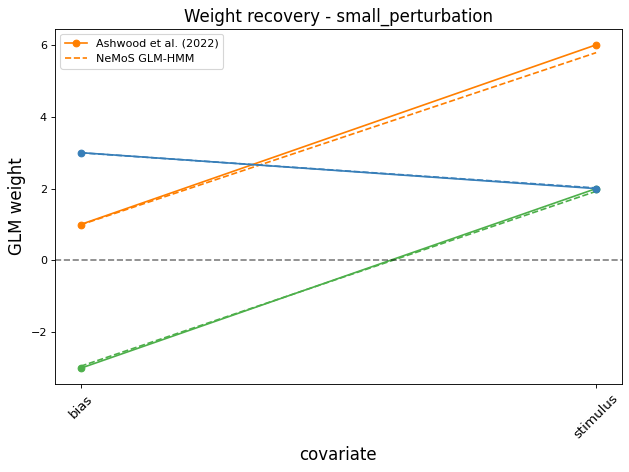

In [ ]:
# Stack array for plotting
stacked_arr = np.stack([true_intercept, true_projection_weights.reshape(n_states)])

plot_glm_weights(
        n_features+1,
        n_states,
        stacked_arr,
        nemos_glm_params[1],
        nemos_glm_params[0],
        X_labels,
        initialization_setting,
    )

## 4. Fitting choices from an IBL mouse and reproducing figures from Ashwood et al. (2022)
- Pending to flip stimulus and bias so they appear exactly as in the paper

### Experimental setup
[TASK EXPLANATION WILL GO HERE + schematic].
Simplified version of Ashwood et a. (2022).

This task was developed by X and adopted by the IBL. During it, a sinusoidal grating with varying contrast [0%-100%] appeared either at the right or left side of the screen. The mice' job was to indicate this side turning a little wheel so that this turn would accordingly move the stimuli to the center of the screen. If it chose the side correctly, it would receive a water reward; if not, a noise burst and a 1 second timeout.

During the first 90 trials of each session, the stimulus appeared randomly on either side of the screen, and after that the stimulus would appear on one side with fixed probability 0.8 and alternate randomly every 20-100 trials. In Ashwood et al. (2020), only the first 90 trials of each session, random appearance at either side, were used.

### Data import and revision
Normally, when importing an IBL dataset, you should follow this process:
XX
However, since we are interested in reproducing a particular set of figures, we will retrieve the already preprocessed data of a single mouse. If you are interested in understanding how this preprocessing took place, please refer to [ashwood's repo]

In [21]:
input, y_raw, session = load_data("IBL/CSHL_008_processed.npz")

X_mouse = input # In the real paper there were 3 inputs: stimuli, Something, something

# Choices
choices_mouse = y_raw.flatten() # Convert to (n_timepoints,)

# new_sess array
# Create array of 1s and 0s marking session boundaries
new_sess_mouse = np.zeros(len(session), dtype=int)
new_sess_mouse[0] = 1  # First entry is always 1

# Mark where session changes
new_sess_mouse[1:] = (session[1:] != session[:-1]).astype(int)
new_sess_mouse

print(np.where(new_sess_mouse==1))

(array([   0,   90,  180,  270,  360,  450,  540,  630,  720,  810,  900,
        990, 1080, 1170, 1260, 1350, 1440, 1530, 1620, 1710, 1800, 1890,
       1980, 2070, 2160, 2250, 2340, 2430, 2520, 2610, 2700, 2790, 2880,
       2970, 3060, 3150, 3240, 3330, 3420, 3510, 3600, 3690, 3780, 3870,
       3960, 4050, 4140, 4230, 4320, 4410, 4500, 4590, 4680, 4770, 4860,
       4950]),)


Animals don't do 3000 trials at once! Instead, they generally do several sessions of 100-300 trials. We use all the sessions together to fit our model. For our model to be accurate, we need to tell it when our session boundaries are: we don't want it to compute two different sessions as if they were one. 

NeMos computes NaNs either in the input matrix X or in the choice vector y as new sessions

!! careful, if your choice data contains nan values, they will be handled as new sessions, so make sure to address this promptly

First I'll initialize with the real ones just for testing then I'll do random noise centered in real values I think

In [22]:
# Initial guess - Initial prob
initial_prob_initial_guess_mouse = true_initial_prob

In [23]:
# True mouse projection weights
X_labels_mouse = ["bias", "stimulus", "Prev.choice", "WSLS"]
projection_weights_true_values_mouse = np.array(
    [
        [6, 2, 2],      # Stimulus,
        [-.1, .1, .2],  # Previous choice
        [-.1, .1, .2]  # Win-stay, lose-switch
        
    ]
    , dtype=float  
)
projection_weights_initial_guess_mouse = projection_weights_true_values_mouse

# True mouse intercept

true_intercept_mouse = true_intercept 
intercept_initial_guess_mouse = true_intercept_mouse

true_transition_prob_mouse = true_transition_prob
transition_prob_initial_guess_mouse = true_transition_prob_mouse
# High proba in diagonal - low elsewhere
#transition_prob_initial_guess_mouse = np.ones(true_transition_prob.shape) * 0.05
#transition_prob_initial_guess_mouse[np.diag_indices(true_transition_prob.shape[1])] = 0.9

In [ ]:
model = nmo.glm_hmm.GLMHMM(3)
model.fit(X_mouse, choices_mouse)

,n_states,3
,observation_model,BernoulliObservations()
,inverse_link_function,<function log...t 0x134a4a7a0>
,regularizer,UnRegularized()
,regularizer_strength,None
,dirichlet_prior_alphas_init_prob,None
,dirichlet_prior_alphas_transition,None
,solver_name,'GradientDescent'
,solver_kwargs,{}
,initialization_funcs,"{'glm_params_init': <function ran...t 0x134ec0c20>, 'initial_proba_init': <function uni...t 0x135d43380>, 'scale_init': <function one...t 0x135d42e80>, 'transition_proba_init': <function sti...t 0x135d42ca0>}"
,maxiter,1000


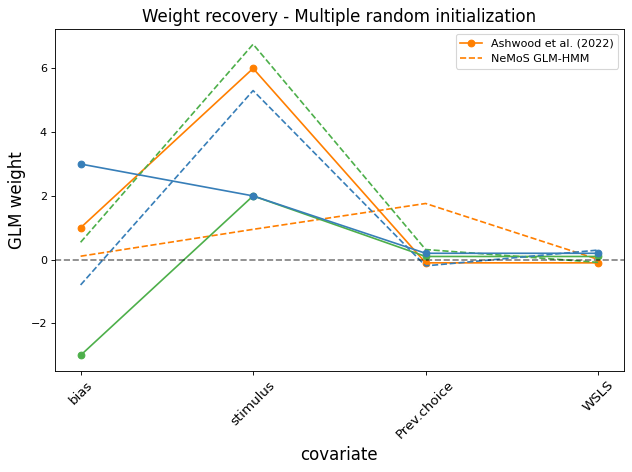

In [33]:
# Stack array for plotting
stacked_arr = np.vstack([true_intercept_mouse, projection_weights_true_values_mouse])
stacked_arr

plot_glm_weights(
    model.coef_.shape[0]+ 1,
    n_states,
    stacked_arr,
    model.intercept_,
    model.coef_,
    X_labels_mouse,
    "Multiple random initialization",
    )


In [24]:
obs = nmo.observation_models.BernoulliObservations()
inverse_link_function = obs.default_inverse_link_function
# Likelihood function & wrapper
log_likelihood_func, negative_log_likelihood_func = prepare_likelihood_func(
    False, obs.log_likelihood, obs._negative_log_likelihood
)

# glm object
glm = nmo.glm.GLM(observation_model=obs, solver_name="LBFGS", solver_kwargs={"tol":1e-12, "maxiter": 5000})
glm.instantiate_solver(partial_hmm_negative_log_likelihood)


# fit
(
        posteriors,
        joint_posterior,
        log_initial_prob,
        log_transition_matrix,
        nemos_glm_params,
        state,
    ) = em_glm_hmm(
            X_mouse,
            choices_mouse,
            initial_prob=initial_prob_initial_guess_mouse,
            transition_prob=transition_prob_initial_guess_mouse,
            glm_params=(projection_weights_initial_guess_mouse,
                        intercept_initial_guess_mouse.reshape(n_states)),
            inverse_link_function=obs.default_inverse_link_function,
            likelihood_func=log_likelihood_func,
            m_step_fn_glm_params=glm._solver_run,
            is_new_session=new_sess_mouse,
            maxiter=5000,
            tol=1e-12,
        )

nemos_initial_prob = log_initial_prob
nemos_transition_prob = log_transition_matrix
predicted_rate_given_state = compute_rate_per_state(
    X_mouse, nemos_glm_params, inverse_link_function
)

log_like_nemos_stack = log_likelihood_func(choices_mouse, predicted_rate_given_state)
log_alphas, log_normalization = forward_pass(
    log_initial_prob,
    log_transition_matrix,
    log_like_nemos_stack,
    new_sess_mouse
)

# Likelihood
_,log_normalization = forward_pass(
    log_initial_prob,
    log_transition_matrix,
    log_like_nemos_stack,
    new_sess_mouse
)
print("\n Fitting complete.")

NameError: name 'prepare_likelihood_func' is not defined

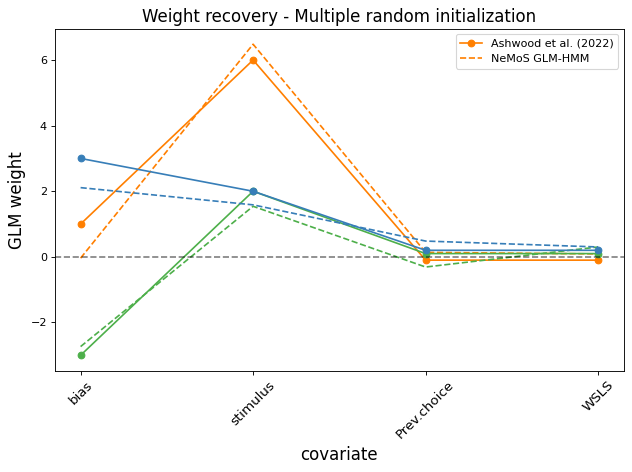

In [ ]:
# Stack array for plotting
stacked_arr = np.vstack([true_intercept_mouse, projection_weights_true_values_mouse])
stacked_arr

plot_glm_weights(
    nemos_glm_params[1].shape[0]+ 1,
    n_states,
    stacked_arr,
    nemos_glm_params[1],
    nemos_glm_params[0],
    X_labels_mouse,
    "Multiple random initialization",
    )


Pending to test whether the likelihood of the recovered parameters is lower or larger than the likelihood of the paper's?

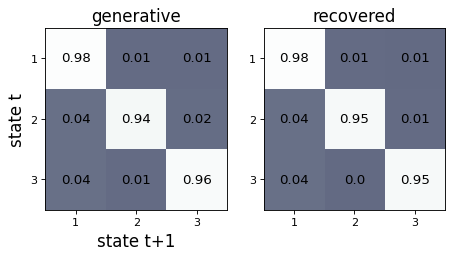

In [ ]:
fig = plt.figure(figsize=(5, 2.5), dpi=80, facecolor='w', edgecolor='k')
plt.subplot(1, 2, 1)
gen_trans_mat = true_transition_prob_mouse
plt.imshow(gen_trans_mat, vmin=-0.8, vmax=1, cmap='bone')
for i in range(gen_trans_mat.shape[0]):
    for j in range(gen_trans_mat.shape[1]):
        text = plt.text(j, i, str(np.around(gen_trans_mat[i, j], decimals=2)), ha="center", va="center",
                        color="k", fontsize=12)
plt.xlim(-0.5, n_states - 0.5)
plt.xticks(range(0, n_states), ('1', '2', '3'), fontsize=10)
plt.yticks(range(0, n_states), ('1', '2', '3'), fontsize=10)
plt.ylim(n_states - 0.5, -0.5)
plt.ylabel("state t", fontsize = 15)
plt.xlabel("state t+1", fontsize = 15)
plt.title("generative", fontsize = 15)


plt.subplot(1, 2, 2)
recovered_trans_mat = np.exp(log_transition_matrix)
plt.imshow(recovered_trans_mat, vmin=-0.8, vmax=1, cmap='bone')
for i in range(recovered_trans_mat.shape[0]):
    for j in range(recovered_trans_mat.shape[1]):
        text = plt.text(j, i, str(np.around(recovered_trans_mat[i, j], decimals=2)), ha="center", va="center",
                        color="k", fontsize=12)
plt.xlim(-0.5, n_states - 0.5)
plt.xticks(range(0, n_states), ('1', '2', '3'), fontsize=10)
plt.yticks(range(0, n_states), ('1', '2', '3'), fontsize=10)
plt.ylim(n_states - 0.5, -0.5)
plt.title("recovered", fontsize = 15)
plt.subplots_adjust(0, 0, 1, 1)

## 5. Fitting comparison: What happens if I use a random initialization?

In [ ]:
###
# 2. FIT SIMULATED DATA WITH ABSOLUTELY RANDOM INITIALIZATION
###
initialization_setting = "random_init"
print(f"Fitting data with {initialization_setting} initialization...")
# PARAMETERS
# Sampling from dirichlet [1,1,1] - all possible triplets that sum to 1 are equally likely
initial_prob_initial_guess = np.random.dirichlet(np.ones(n_states))
print("--Initial probability guess: \n ", initial_prob_initial_guess)
print("--Check it sums to 1", initial_prob_initial_guess.sum())
# Normalization is not necessary anymore since dirichlet already sums to 1

# Random projection weights
projection_weights_initial_guess = true_projection_weights + np.random.randn(
    *true_projection_weights.shape
)
print("Initial projection weights guess: \n", projection_weights_initial_guess)

# Random transition matrix
transition_prob_initial_guess = np.random.dirichlet(np.ones(n_states), size=3)
print("Initial transition probability guess \n", transition_prob_initial_guess)
print("--Check it sums to 1", transition_prob_initial_guess.sum(axis=1))


Fitting data with random_init initialization...
--Initial probability guess: 
  [0.57779538 0.10152184 0.32068278]
--Check it sums to 1 1.0
Initial projection weights guess: 
 [[4.85540242 1.34965063 2.07137782]]
Initial transition probability guess 
 [[0.15308454 0.79937076 0.04754469]
 [0.39412458 0.42037164 0.18550379]
 [0.05483545 0.8656564  0.07950815]]
--Check it sums to 1 [1. 1. 1.]


In [ ]:

# This is no better than starting from a slightly perturbed version of the true parameters
def compare_likelihoods(log_likelihoods):
    print(f"Log likelihoods from different initializations: \n {log_likelihoods}")
    return None


###
# 3. FIT SIMULATED DATA WITH "TILTED" INITIALIZATION
# As in Iris paper
###

###
# 4. FIT SIMULATED DATA WITH K-MEANS ALGORITHM

###
###
# 5. COMPARE LIKELIHOODS
###
compare_likelihoods(log_likelihoods)

Log likelihoods from different initializations: 
 {}


Takaaway: the initialization parameters matter. The reason why they matter is the algorithm we use to fit the GLM-HMM: Expectation Maximization algorithm. Please, refer to the other notebook to learn more about that.

## Conclusion

## Other resources

## References